# Session 6: Bayesian Computation — Monte Carlo Estimation & Sampling Methods

**Bayesian Analysis of Empirical Data (2026)**  
*Author: Irina Knyazeva*

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/iknyazeva/bayes-cogsci-book/blob/main/notebooks/colab/06_bayesian_computation.ipynb)

---

## Learning Goals
1. **Understand Monte Carlo Integration**: Replace complex calculus and integration with sample averages over simulated draws.
2. **Estimate Bayesian Estimands**: Compute posterior means, tail hypothesis probabilities, and non-linear transformations (e.g. Odds, log-odds) without Jacobian calculations.
3. **Master Sampling Algorithms**: Implement the Inverse CDF method, Box-Muller transform, and **Rejection Sampling** from scratch.
4. **Quantify Simulation Error**: Calculate Monte Carlo Standard Error (MCSE) and verify the $1/\sqrt{S}$ square-root law.

In [1]:
# Setup & Dependencies
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Set random seed for exact reproducibility
rng = np.random.default_rng(2026)
print("NumPy & SciPy loaded successfully!")

NumPy & SciPy loaded successfully!


---
## 1. Geometric Monte Carlo: Estimating $\pi$ via Uniform Darts

The foundational intuition of Monte Carlo: **calculating an area or volume is equivalent to counting random points**.

Consider a unit circle ($x^2 + y^2 \le 1$, area $\pi$) inscribed in a square $[-1, 1] \times [-1, 1]$ (area $4$).
The probability that a uniformly distributed dart lands inside the circle is:
$$P(\text{inside}) = \frac{\pi}{4} \implies \widehat\pi = 4 \times \frac{1}{S} \sum_{s=1}^S \mathbb{I}(x_s^2 + y_s^2 \le 1)$$

Estimated π (10,000 draws): 3.1536 ± 0.0320
True π: 3.1416, Absolute Error: 0.0120


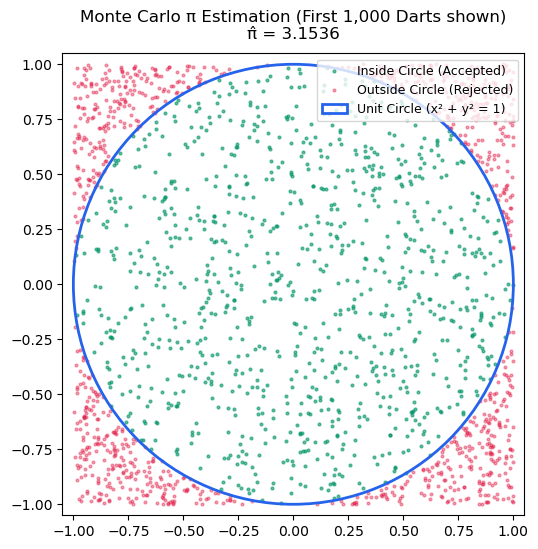

In [2]:
S = 10_000

# 1. Throw S random darts uniformly into [-1, 1] x [-1, 1]
x = rng.uniform(-1.0, 1.0, size=S)
y = rng.uniform(-1.0, 1.0, size=S)

# 2. Indicator condition: does dart land inside unit circle?
inside = (x**2 + y**2) <= 1.0

# 3. Estimate pi and Monte Carlo Standard Error
pi_hat = 4.0 * np.mean(inside)
mcse_pi = 4.0 * np.std(inside, ddof=1) / np.sqrt(S)

print(f"Estimated π ({S:,} draws): {pi_hat:.4f} ± {1.96 * mcse_pi:.4f}")
print(f"True π: {np.pi:.4f}, Absolute Error: {abs(pi_hat - np.pi):.4f}")

# Visualization
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(x[inside][:1000], y[inside][:1000], color='#059669', s=4, alpha=0.6, label='Inside Circle (Accepted)')
ax.scatter(x[~inside][:1000], y[~inside][:1000], color='#e11d48', s=4, alpha=0.4, label='Outside Circle (Rejected)')
circle = plt.Circle((0, 0), 1.0, color='#2563eb', fill=False, linewidth=2, label='Unit Circle (x² + y² = 1)')
ax.add_patch(circle)
ax.set_xlim(-1.05, 1.05)
ax.set_ylim(-1.05, 1.05)
ax.set_aspect('equal')
ax.set_title(f"Monte Carlo π Estimation (First 1,000 Darts shown)\nπ̂ = {pi_hat:.4f}", fontsize=12, pad=10)
ax.legend(loc='upper right', fontsize=9)
plt.show()

---
## 2. Applied Bayesian Inference: The Beta–Binomial Posterior

In Session 4, observing $k = 7$ successes out of $N = 10$ trials yielded the exact posterior:
$$\theta \mid y \sim \operatorname{Beta}(\alpha = 8, \; \beta = 4)$$

With Monte Carlo simulation, answering substantive scientific questions requires **zero calculus**:

In [3]:
# Draw S samples from posterior Beta(8, 4)
theta_draws = rng.beta(a=8, b=4, size=S)

# 1. Posterior Mean
mean_hat = theta_draws.mean()
mcse_mean = theta_draws.std(ddof=1) / np.sqrt(S)
print(f"1. Posterior Mean: {mean_hat:.4f} ± {1.96*mcse_mean:.4f} (Analytic Truth: {8/12:.4f})")

# 2. Hypothesis / Tail Probability
is_competent = theta_draws > 0.60
p_competent = np.mean(is_competent)
mcse_p = np.std(is_competent, ddof=1) / np.sqrt(S)
print(f"2. P(θ > 0.60): {p_competent:.4f} ± {1.96*mcse_p:.4f} (Analytic Truth: 0.7037)")

# 3. Non-linear Transformation to Odds: ω = θ / (1 - θ)
odds_draws = theta_draws / (1.0 - theta_draws)
print(f"3. Posterior Median Odds: {np.median(odds_draws):.2f}")
print(f"   True Expected Odds E[ω]: {odds_draws.mean():.2f}")
print(f"   Plug-in Naive Odds g(E[θ]): {mean_hat / (1.0 - mean_hat):.2f}")
print("   -> Notice Jensen's Inequality: E[g(θ)] ≠ g(E[θ])!")

1. Posterior Mean: 0.6662 ± 0.0025 (Analytic Truth: 0.6667)
2. P(θ > 0.60): 0.7069 ± 0.0089 (Analytic Truth: 0.7037)
3. Posterior Median Odds: 2.08
   True Expected Odds E[ω]: 2.63
   Plug-in Naive Odds g(E[θ]): 2.00
   -> Notice Jensen's Inequality: E[g(θ)] ≠ g(E[θ])!


---
## 3. How Computers Sample from Non-Uniform Distributions

Physical CPUs only produce uniform pseudo-random integers $U \sim \operatorname{Uniform}(0, 1)$.
How do algorithms transform uniform random numbers into continuous distributions?

### Method 1: The Inverse CDF Method
If the cumulative distribution function $F(x) = P(X \le x)$ has an analytical inverse $F^{-1}(u)$, then:
$$X = F^{-1}(U) \sim F$$

For an Exponential distribution ($F(x) = 1 - e^{-\lambda x}$):
$$X = -\frac{\ln(1 - U)}{\lambda}$$

In [4]:
# Method 1: Exponential via Inverse CDF
lam = 2.0  # Rate parameter
u = rng.uniform(0, 1, size=S)
x_exp_custom = -np.log(1.0 - u) / lam

print(f"Inverse CDF Exponential Mean: {x_exp_custom.mean():.4f} (Theoretical: {1/lam:.4f})")

Inverse CDF Exponential Mean: 0.4945 (Theoretical: 0.5000)


### Method 2: The Box–Muller Transform for Gaussians
Maps two independent uniforms $(U_1, U_2)$ into two independent standard Normal draws $(Z_1, Z_2)$:
$$Z_1 = \sqrt{-2\ln U_1}\cos(2\pi U_2), \qquad Z_2 = \sqrt{-2\ln U_1}\sin(2\pi U_2)$$

In [5]:
# Method 2: Box-Muller Normal Generator
u1 = rng.uniform(0, 1, size=S//2)
u2 = rng.uniform(0, 1, size=S//2)

r = np.sqrt(-2.0 * np.log(u1))
theta_angle = 2.0 * np.pi * u2
z1 = r * np.cos(theta_angle)
z2 = r * np.sin(theta_angle)
z_custom = np.concatenate([z1, z2])

print(f"Box-Muller Normal Mean: {z_custom.mean():.4f}, Std: {z_custom.std():.4f} (Theoretical: 0.00, 1.00)")

Box-Muller Normal Mean: -0.0076, Std: 0.9999 (Theoretical: 0.00, 1.00)


### Method 3: Rejection Sampling

When neither the inverse CDF nor an exact geometric transformation exists, **Rejection Sampling** allows us to sample from any target density $p(\theta)$ using an easy-to-sample proposal density $q(\theta)$ and an envelope constant $M$ such that:
$$M \cdot q(\theta) \ge p(\theta) \quad \text{for all } \theta$$

**Algorithm:**
1. Sample a candidate draw $\theta^* \sim q(\theta)$.
2. Sample a uniform vertical height $u \sim \operatorname{Uniform}(0, M \cdot q(\theta^*))$.
3. **Acceptance Rule**: If $u \le p(\theta^*)$, accept $\theta^*$; otherwise, reject and discard it.
4. **Acceptance Rate**: The probability of acceptance is exactly $\frac{1}{M}$.

In [6]:
# Rejection Sampling for Target Beta(2.5, 3.5)
a, b = 2.5, 3.5
target_pdf = lambda th: stats.beta.pdf(th, a, b)

# Proposal: Uniform(0, 1) -> q(theta) = 1.0
# Envelope M >= max(Beta(2.5, 3.5)) = 1.861
M = 2.10

def sample_rejection(n_proposals):
    th_candidates = rng.uniform(0.0, 1.0, size=n_proposals)
    u_heights = rng.uniform(0.0, M, size=n_proposals)
    
    accepted_mask = u_heights <= target_pdf(th_candidates)
    accepted_draws = th_candidates[accepted_mask]
    
    return th_candidates, u_heights, accepted_mask, accepted_draws

N_PROP = 5_000
cands, heights, is_acc, accepted = sample_rejection(N_PROP)

emp_rate = len(accepted) / N_PROP
theo_rate = 1.0 / M

print(f"Total Proposed: {N_PROP:,}")
print(f"Total Accepted: {len(accepted):,} ({emp_rate*100:.2f}%)")
print(f"Theoretical Acceptance Rate (1/M): {theo_rate*100:.2f}%")
print(f"Sample Mean: {accepted.mean():.4f} (True Beta Mean: {a/(a+b):.4f})")

Total Proposed: 5,000
Total Accepted: 2,386 (47.72%)
Theoretical Acceptance Rate (1/M): 47.62%
Sample Mean: 0.4113 (True Beta Mean: 0.4167)


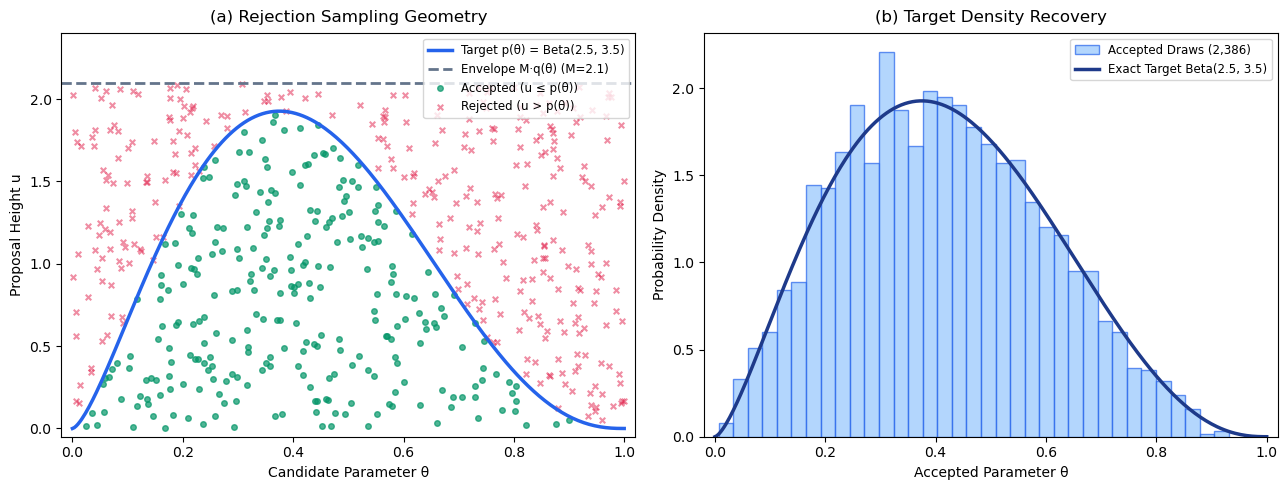

In [7]:
# Visualizing Rejection Sampling Geometry & Target Recovery
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
th_grid = np.linspace(0, 1, 300)

# Panel 1: Geometry (First 600 proposals shown)
sub = 600
ax1.plot(th_grid, target_pdf(th_grid), color='#2563eb', lw=2.5, label='Target p(θ) = Beta(2.5, 3.5)')
ax1.axhline(M, color='#64748b', ls='--', lw=2, label=f'Envelope M·q(θ) (M={M})')
ax1.scatter(cands[:sub][is_acc[:sub]], heights[:sub][is_acc[:sub]], color='#059669', s=16, alpha=0.7, label='Accepted (u ≤ p(θ))')
ax1.scatter(cands[:sub][~is_acc[:sub]], heights[:sub][~is_acc[:sub]], color='#e11d48', s=16, marker='x', alpha=0.5, label='Rejected (u > p(θ))')
ax1.set_xlim(-0.02, 1.02)
ax1.set_ylim(-0.05, M + 0.3)
ax1.set_title("(a) Rejection Sampling Geometry", fontsize=12, pad=8)
ax1.set_xlabel("Candidate Parameter θ", fontsize=10)
ax1.set_ylabel("Proposal Height u", fontsize=10)
ax1.legend(loc='upper right', fontsize=8.5)

# Panel 2: Target Recovery (Histogram of Accepted Draws)
ax2.hist(accepted, bins=35, density=True, color='#93c5fd', edgecolor='#2563eb', alpha=0.7, label=f'Accepted Draws ({len(accepted):,})')
ax2.plot(th_grid, target_pdf(th_grid), color='#1e3a8a', lw=2.5, label='Exact Target Beta(2.5, 3.5)')
ax2.set_xlim(-0.02, 1.02)
ax2.set_title("(b) Target Density Recovery", fontsize=12, pad=8)
ax2.set_xlabel("Accepted Parameter θ", fontsize=10)
ax2.set_ylabel("Probability Density", fontsize=10)
ax2.legend(loc='upper right', fontsize=8.5)

plt.tight_layout()
plt.show()

---
## 4. The Gamma Benchmark: Running Means & The Square-Root Law

Under the Central Limit Theorem, Monte Carlo Standard Error (numerical simulation noise) decays with the number of draws $S$:
$$\operatorname{MCSE}(\widehat\mu_g) = \frac{s_g}{\sqrt{S}}$$

Halving the numerical simulation error requires **four times ($4\times$) as many draws**.

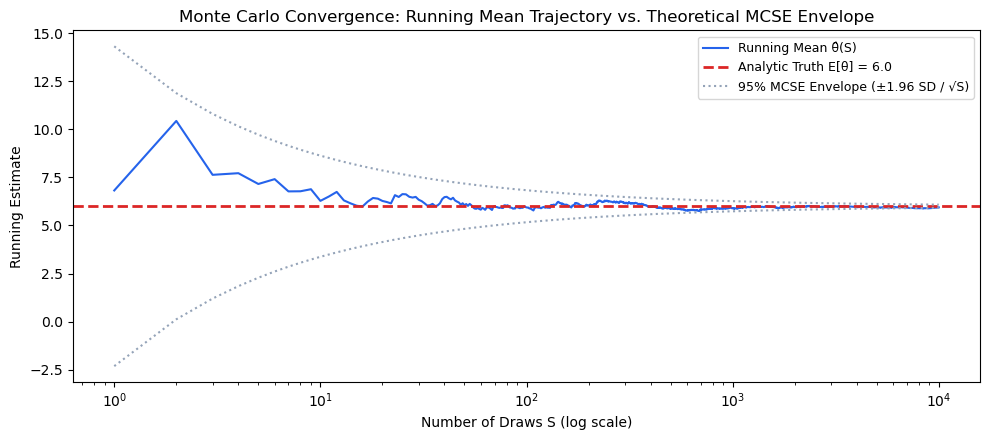

In [8]:
# Gamma(shape=2, scale=3) benchmark: True Mean = 6.0
draws = rng.gamma(shape=2, scale=3, size=10_000)

# Running mean trajectory
indices = np.arange(1, len(draws) + 1)
running_means = np.cumsum(draws) / indices
theoretical_sd = np.sqrt(2 * (3**2))  # SD = sqrt(k * theta^2) = sqrt(18) = 4.2426
mcse_envelope = 1.96 * (theoretical_sd / np.sqrt(indices))

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(indices, running_means, color='#2563eb', lw=1.5, label='Running Mean θ̂(S)')
ax.axhline(6.0, color='#dc2626', ls='--', lw=2, label='Analytic Truth E[θ] = 6.0')
ax.plot(indices, 6.0 + mcse_envelope, color='#94a3b8', ls=':', label='95% MCSE Envelope (±1.96 SD / √S)')
ax.plot(indices, 6.0 - mcse_envelope, color='#94a3b8', ls=':')
ax.set_xscale('log')
ax.set_xlabel('Number of Draws S (log scale)', fontsize=10)
ax.set_ylabel('Running Estimate', fontsize=10)
ax.set_title('Monte Carlo Convergence: Running Mean Trajectory vs. Theoretical MCSE Envelope', fontsize=12)
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

---
## 5. Student Sandbox: Your Turn!

### Challenge 1: The Ex-Gaussian Reaction Time Mixture
In cognitive psychology, response times (RT) often follow an **Ex-Gaussian distribution** (Gaussian decision latency + Exponential attentional tail):
$$\text{RT} = X_{\text{Normal}} + X_{\text{Exponential}}, \quad X_N \sim \operatorname{Normal}(\mu=350\text{ ms}, \sigma=40), \; X_E \sim \operatorname{Exponential}(\beta=80\text{ ms})$$

Using $S = 20{,}000$ draws:
1. Compute the expected RT: $\mathbb{E}[\text{RT}]$.
2. Compute the probability of an "attentional lapse" (defined as $\text{RT} > 600\text{ ms}$).
3. Compute the $95\%$ equal-tailed interval $[q_{0.025}, q_{0.975}]$ for response times.

In [9]:
# --- STUDENT SANDBOX: CHALLENGE 1 ---
# TODO: Implement Ex-Gaussian RT simulation

S_sim = 20_000
rt_norm = rng.normal(loc=350, scale=40, size=S_sim)
rt_exp = rng.exponential(scale=80, size=S_sim)
rt_total = rt_norm + rt_exp

# 1. Expected RT
print(f"Mean RT: {rt_total.mean():.1f} ms (Theoretical: {350 + 80} ms)")

# 2. Lapse Probability (RT > 600 ms)
prob_lapse = np.mean(rt_total > 600)
print(f"Lapse Probability (RT > 600ms): {prob_lapse*100:.2f}%")

# 3. 95% Quantiles
q_low, q_high = np.quantile(rt_total, [0.025, 0.975])
print(f"95% Central Interval: [{q_low:.1f} ms, {q_high:.1f} ms]")

Mean RT: 431.1 ms (Theoretical: 430 ms)
Lapse Probability (RT > 600ms): 5.14%
95% Central Interval: [303.7 ms, 655.3 ms]
